# Lab 8. Word Embeddings: From Co-occurrence to Geometry

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-08-word-embeddings.ipynb)

This lab accompanies Chapter 8 of **Mathematical Natural Language Processing**.

The central pipeline is:

$$
\text{text corpus} \longrightarrow \text{word-context pairs} \longrightarrow \text{co-occurrence matrix} \longrightarrow \text{PPMI matrix} \longrightarrow \text{SVD embeddings} \longrightarrow \text{geometry}.
$$

You will also implement a small negative-sampling training loop, which gives a first view of prediction-based word embeddings.


## Learning goals

By the end of this lab, you should be able to:

1. explain the difference between one-hot vectors and dense word embeddings;
2. construct word-context pairs from a tokenized corpus;
3. build a co-occurrence matrix;
4. compute empirical joint, marginal, and conditional probabilities;
5. compute PMI and PPMI;
6. obtain word embeddings from a PPMI matrix using SVD;
7. use cosine similarity for nearest-neighbor search;
8. visualize a two-dimensional embedding space;
9. explain analogy arithmetic as a geometric operation;
10. implement a small skip-gram negative-sampling model from scratch;
11. critique the limitations of static word embeddings.


## Mathematical background before programming

A **word embedding** is a function

$$
e:V \to R^m,
$$

where $V$ is a finite vocabulary and $m$ is the embedding dimension.

If $V=\{v_1,\dots,v_d\}$, a one-hot representation of $v_j$ is the vector

$$
\delta_j=(0,\dots,0,1,0,\dots,0)^T \in R^d.
$$

One-hot vectors are exact but not semantic. For two different words $v_i$ and $v_j$,

$$
\delta_i^T\delta_j=0.
$$

Thus all distinct words are equally far apart.

A dense embedding stores vectors in a matrix

$$
E\in R^{d\times m}.
$$

The embedding of $v_j$ is the $j$th row $E_{j:}$. If a token is represented by $\delta_j$, then

$$
\delta_j^T E = E_{j:}.
$$

This is the linear algebra behind an embedding lookup.


## Distributional hypothesis

The guiding principle is:

> Words that occur in similar contexts tend to have related meanings.

Mathematically, each word $w$ can be described by a context distribution

$$
P(C=c\mid W=w).
$$

Two words are distributionally similar when their context distributions are similar. Word embeddings are low-dimensional summaries of these context distributions.


## Setup

This lab uses only standard scientific Python libraries. Everything is small enough to run quickly in Google Colab.


In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7243)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Setup complete.")


Setup complete.


# Part 1. One-hot vectors and embedding lookup

We begin with a tiny vocabulary and a hand-made embedding matrix so that the lookup operation is visible.


In [2]:
vocab_demo = ["token", "word", "vector", "matrix"]
word_to_id_demo = {w: i for i, w in enumerate(vocab_demo)}

E_demo = np.array([
    [1.0, 0.2],   # token
    [0.9, 0.1],   # word
    [0.1, 1.0],   # vector
    [0.2, 0.9],   # matrix
])

j = word_to_id_demo["vector"]
one_hot = np.zeros(len(vocab_demo))
one_hot[j] = 1.0

lookup = one_hot @ E_demo

print("one-hot vector for 'vector':", one_hot)
print("embedding from one_hot @ E_demo:", lookup)
print("same row directly from E_demo:", E_demo[j])


one-hot vector for 'vector': [0. 0. 1. 0.]
embedding from one_hot @ E_demo: [0.1 1. ]
same row directly from E_demo: [0.1 1. ]


**Checkpoint.** The one-hot vector selects a row of the embedding matrix. In neural NLP, this lookup matrix is usually trainable.


# Part 2. A small corpus for word embeddings

We will use a small educational corpus. It is not large enough for high-quality embeddings, but it is perfect for seeing all mathematical objects clearly.


In [3]:
corpus = [
    "linear algebra studies vectors matrices spaces transformations",
    "eigenvectors singular values matrices reveal geometric structure",
    "probability models uncertainty randomness data distributions",
    "statistics estimates parameters from data and evaluates models",
    "language models predict words from context and data",
    "tokens words contexts vocabularies are central to language processing",
    "word embeddings represent words as vectors in semantic space",
    "context helps determine meaning for words and phrases",
    "neural networks learn embeddings through prediction objectives",
    "optimization trains models by minimizing loss functions",
    "graph nodes edges and walks represent relations in networks",
    "retrieval systems compare query vectors with document vectors",
    "teacher student lecture theorem proof classroom university",
    "professor student course lecture homework exam university",
    "doctor nurse patient hospital medicine clinic treatment",
    "king queen prince princess palace royal throne crown",
    "man woman boy girl person family parent child",
    "cat dog animal pet kitten puppy household companion",
]

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

tokenized = [tokenize(doc) for doc in corpus]

print("Number of documents:", len(tokenized))
print("First two tokenized documents:")
for doc in tokenized[:2]:
    print(doc)


Number of documents: 18
First two tokenized documents:
['linear', 'algebra', 'studies', 'vectors', 'matrices', 'spaces', 'transformations']
['eigenvectors', 'singular', 'values', 'matrices', 'reveal', 'geometric', 'structure']


## Build the vocabulary

We keep all words in this small lab. For a larger corpus, you would usually remove extremely rare words or map them to an unknown token.


In [4]:
counts = Counter(token for doc in tokenized for token in doc)
vocab = sorted(counts)
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

d = len(vocab)
print("Vocabulary size:", d)
print(vocab[:40])


Vocabulary size: 113
['algebra', 'and', 'animal', 'are', 'as', 'boy', 'by', 'cat', 'central', 'child', 'classroom', 'clinic', 'companion', 'compare', 'context', 'contexts', 'course', 'crown', 'data', 'determine', 'distributions', 'doctor', 'document', 'dog', 'edges', 'eigenvectors', 'embeddings', 'estimates', 'evaluates', 'exam', 'family', 'for', 'from', 'functions', 'geometric', 'girl', 'graph', 'helps', 'homework', 'hospital']


# Part 3. Word-context pairs

Choose a context window radius $h$. For a token at position $t$, its context words are tokens with positions $s$ satisfying

$$
0 < |s-t| \leq h.
$$

For example, if $h=2$, each center word can look up to two tokens to the left and two tokens to the right.


In [5]:
def make_word_context_pairs(tokenized_docs, word_to_id, window=2):
    pairs = []
    for doc in tokenized_docs:
        ids = [word_to_id[w] for w in doc]
        for t, center_id in enumerate(ids):
            left = max(0, t - window)
            right = min(len(ids), t + window + 1)
            for s in range(left, right):
                if s != t:
                    pairs.append((center_id, ids[s]))
    return pairs

pairs = make_word_context_pairs(tokenized, word_to_id, window=2)

print("Number of word-context pairs:", len(pairs))
print("First 15 pairs:")
for i, j in pairs[:15]:
    print(f"({id_to_word[i]}, {id_to_word[j]})")


Number of word-context pairs: 444
First 15 pairs:
(linear, algebra)
(linear, studies)
(algebra, linear)
(algebra, studies)
(algebra, vectors)
(studies, linear)
(studies, algebra)
(studies, vectors)
(studies, matrices)
(vectors, algebra)
(vectors, studies)
(vectors, matrices)
(vectors, spaces)
(matrices, studies)
(matrices, vectors)


## Exercise pause

Before running the next cell, predict what happens when the window changes from $h=2$ to $h=1$ or $h=3$.

- Smaller windows emphasize syntax and local phrases.
- Larger windows emphasize broader topical association.


In [6]:
for h in [1, 2, 3]:
    n_pairs = len(make_word_context_pairs(tokenized, word_to_id, window=h))
    print(f"window={h}: {n_pairs} word-context pairs")


window=1: 240 word-context pairs
window=2: 444 word-context pairs
window=3: 612 word-context pairs


# Part 4. Co-occurrence matrix

The co-occurrence matrix $C\in R^{d\times d}$ is defined by

$$
C_{ij}=\#\{(w,c): w=v_i, c=v_j\}.
$$

Rows are center words. Columns are context words.


In [7]:
def cooccurrence_matrix(pairs, vocab_size):
    C = np.zeros((vocab_size, vocab_size), dtype=float)
    for center_id, context_id in pairs:
        C[center_id, context_id] += 1.0
    return C

C = cooccurrence_matrix(pairs, d)
C_df = pd.DataFrame(C, index=vocab, columns=vocab)

selected_words = ["language", "models", "words", "vectors", "student", "king", "queen", "doctor", "nurse"]
selected_words = [w for w in selected_words if w in word_to_id]
C_df.loc[selected_words, selected_words]


,language,models,words,vectors,student,king,queen,doctor,nurse
language,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
models,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
words,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
vectors,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
student,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
king,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
queen,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
doctor,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
nurse,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


A row of $C$ is a high-dimensional context-count vector for a word. We can inspect the largest context counts for selected words.


In [8]:
def top_contexts(word, C, k=8):
    i = word_to_id[word]
    row = C[i]
    order = np.argsort(-row)
    result = []
    for j in order:
        if row[j] > 0:
            result.append((id_to_word[j], row[j]))
        if len(result) == k:
            break
    return pd.DataFrame(result, columns=["context", "count"])

for word in ["language", "student", "king", "doctor"]:
    print(f"Top contexts for {word!r}")
    display(top_contexts(word, C, k=6))


Top contexts for 'language'


,context,count
0,central,1.0
1,models,1.0
2,processing,1.0
3,predict,1.0
4,to,1.0


Top contexts for 'student'


,context,count
0,lecture,2.0
1,course,1.0
2,theorem,1.0
3,professor,1.0
4,teacher,1.0


Top contexts for 'king'


,context,count
0,queen,1.0
1,prince,1.0


Top contexts for 'doctor'


,context,count
0,nurse,1.0
1,patient,1.0


# Part 5. Empirical probabilities

Let

$$
N=\sum_{i,j} C_{ij}.
$$

Then the empirical joint distribution is

$$
\widehat P(W=v_i,C=v_j)=\frac{C_{ij}}{N}.
$$

The empirical marginals are

$$
\widehat P(W=v_i)=\frac{\sum_j C_{ij}}{N},
\qquad
\widehat P(C=v_j)=\frac{\sum_i C_{ij}}{N}.
$$

The empirical conditional context distribution is

$$
\widehat P(C=v_j\mid W=v_i)=\frac{C_{ij}}{\sum_k C_{ik}}.
$$


In [9]:
N = C.sum()
P_joint = C / N
P_word = C.sum(axis=1) / N
P_context = C.sum(axis=0) / N

row_sums = C.sum(axis=1, keepdims=True)
P_context_given_word = np.divide(C, row_sums, out=np.zeros_like(C), where=row_sums > 0)

word = "language"
i = word_to_id[word]
cond = pd.DataFrame({
    "context": vocab,
    f"P(context | {word})": P_context_given_word[i]
}).sort_values(f"P(context | {word})", ascending=False)

cond.head(10)


,context,P(context | language)
8,central,0.2
98,to,0.2
73,processing,0.2
68,predict,0.2
54,models,0.2
0,algebra,0.0
1,and,0.0
3,are,0.0
2,animal,0.0
9,child,0.0


# Part 6. PMI and PPMI

Raw counts are influenced by word frequency. PMI compares observed co-occurrence against what would be expected under independence:

$$
\operatorname{PMI}(w,c)=\log\frac{P(w,c)}{P(w)P(c)}.
$$

Positive PMI keeps only positive association:

$$
\operatorname{PPMI}(w,c)=\max\{\operatorname{PMI}(w,c),0\}.
$$


In [10]:
def pmi_matrix(C, eps=1e-12):
    total = C.sum()
    row_sum = C.sum(axis=1, keepdims=True)
    col_sum = C.sum(axis=0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        PMI = np.log((C * total + eps) / (row_sum @ col_sum + eps))
    PMI[C == 0] = 0.0
    return PMI

def ppmi_matrix(C):
    return np.maximum(pmi_matrix(C), 0.0)

PMI = pmi_matrix(C)
PPMI = ppmi_matrix(C)

PMI_df = pd.DataFrame(PMI, index=vocab, columns=vocab)
PPMI_df = pd.DataFrame(PPMI, index=vocab, columns=vocab)

PPMI_df.loc[selected_words, selected_words].round(2)


,language,models,words,vectors,student,king,queen,doctor,nurse
language,0.0,2.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
models,2.0,0.0,0.90,0.00,0.0,0.0,0.0,0.0,0.0
words,0.0,0.9,0.00,0.75,0.0,0.0,0.0,0.0,0.0
vectors,0.0,0.0,0.75,0.00,0.0,0.0,0.0,0.0,0.0
student,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
king,0.0,0.0,0.00,0.00,0.0,0.0,4.3,0.0,0.0
queen,0.0,0.0,0.00,0.00,0.0,4.3,0.0,0.0,0.0
doctor,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,4.3
nurse,0.0,0.0,0.00,0.00,0.0,0.0,0.0,4.3,0.0


## Largest PMI pairs

The largest PMI pairs are not always the most frequent pairs. PMI emphasizes pairs that occur more often than expected relative to their marginal frequencies.


In [11]:
def top_pmi_pairs(PMI, C, k=15):
    rows = []
    for i in range(PMI.shape[0]):
        for j in range(PMI.shape[1]):
            if C[i, j] > 0:
                rows.append((id_to_word[i], id_to_word[j], C[i, j], PMI[i, j]))
    rows.sort(key=lambda x: x[3], reverse=True)
    return pd.DataFrame(rows[:k], columns=["word", "context", "count", "PMI"])

top_pmi_pairs(PMI, C, k=15)


,word,context,count,PMI
0,algebra,linear,1.0,4.304065
1,cat,dog,1.0,4.304065
2,child,parent,1.0,4.304065
3,clinic,treatment,1.0,4.304065
4,companion,household,1.0,4.304065
5,crown,throne,1.0,4.304065
6,doctor,nurse,1.0,4.304065
7,dog,cat,1.0,4.304065
8,eigenvectors,singular,1.0,4.304065
9,estimates,statistics,1.0,4.304065


# Part 7. SVD embeddings from the PPMI matrix

Let $M$ be the PPMI matrix. The singular value decomposition is

$$
M=U\Sigma V^T.
$$

A rank-$m$ embedding can be constructed as

$$
E=U_m\Sigma_m^{1/2}.
$$

This gives each word a vector in $R^m$.


In [12]:
def svd_embeddings(M, m=2):
    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    E = U[:, :m] * np.sqrt(s[:m])
    F = Vt[:m, :].T * np.sqrt(s[:m])
    return E, F, s

E2, F2, singular_values = svd_embeddings(PPMI, m=2)
E5, F5, _ = svd_embeddings(PPMI, m=5)

emb2_df = pd.DataFrame(E2, index=vocab, columns=["z1", "z2"])
emb2_df.head(10)


,z1,z2
algebra,1.788079e-01,1.173729e-16
and,9.617728e-01,1.290256e-16
animal,-2.052287e-16,4.040797e-15
are,4.405805e-01,-1.016665e-16
as,4.919218e-01,6.336915e-17
boy,0.000000e+00,1.790108e-15
by,4.027949e-01,-1.337855e-16
cat,2.565359e-17,2.499449e-15
central,4.436079e-01,3.622502e-16
child,-2.244689e-17,8.607034e-16


## How much energy is captured?

For SVD, the squared singular values measure Frobenius energy. The cumulative energy ratio is

$$
\frac{\sum_{r=1}^m \sigma_r^2}{\sum_{r=1}^d \sigma_r^2}.
$$


In [13]:
energy = singular_values**2
cumulative_energy = np.cumsum(energy) / energy.sum()

energy_df = pd.DataFrame({
    "dimension": np.arange(1, len(singular_values) + 1),
    "singular_value": singular_values,
    "cumulative_energy": cumulative_energy
})

energy_df.head(10)


,dimension,singular_value,cumulative_energy
0,1,13.668342,0.041288
1,2,13.113295,0.079291
2,3,12.674214,0.114791
3,4,12.382908,0.148678
4,5,12.382908,0.182565
5,6,12.382908,0.216452
6,7,12.193363,0.249310
7,8,12.145369,0.281910
8,9,11.474423,0.311007
9,10,11.215773,0.338807


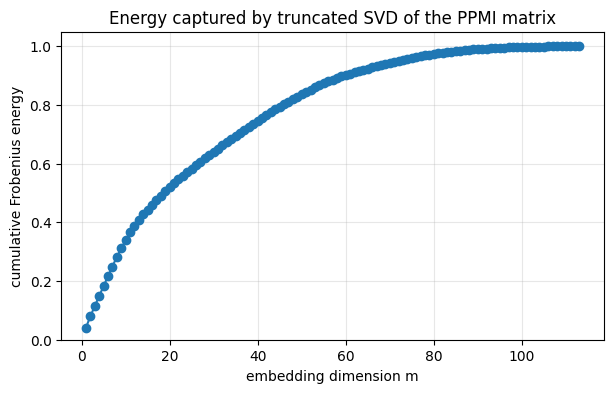

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(energy_df["dimension"], energy_df["cumulative_energy"], marker="o")
plt.xlabel("embedding dimension m")
plt.ylabel("cumulative Frobenius energy")
plt.title("Energy captured by truncated SVD of the PPMI matrix")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()


# Part 8. Cosine similarity and nearest neighbors

For nonzero vectors $x,y\in R^m$, cosine similarity is

$$
\operatorname{cos}(x,y)=\frac{x^Ty}{\|x\|_2\|y\|_2}.
$$

Cosine similarity focuses on direction rather than length.


In [15]:
def row_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def nearest_neighbors(word, E, k=8):
    if word not in word_to_id:
        raise ValueError(f"{word!r} is not in the vocabulary")
    idx = word_to_id[word]
    En = row_normalize(E)
    scores = En @ En[idx]
    order = np.argsort(-scores)
    rows = []
    for j in order:
        if j == idx:
            continue
        rows.append((id_to_word[j], float(scores[j])))
        if len(rows) == k:
            break
    return pd.DataFrame(rows, columns=["neighbor", "cosine"])

for word in ["language", "vectors", "student", "king", "doctor"]:
    print(f"Nearest neighbors of {word!r} using rank-5 PPMI-SVD embeddings")
    display(nearest_neighbors(word, E5, k=6))


Nearest neighbors of 'language' using rank-5 PPMI-SVD embeddings


,neighbor,cosine
0,to,0.999999
1,distributions,0.999983
2,models,0.999982
3,randomness,0.999835
4,uncertainty,0.999615
5,processing,0.999379


Nearest neighbors of 'vectors' using rank-5 PPMI-SVD embeddings


,neighbor,cosine
0,document,0.998758
1,with,0.997896
2,query,0.995769
3,compare,0.994784
4,algebra,0.993071
5,semantic,0.992266


Nearest neighbors of 'student' using rank-5 PPMI-SVD embeddings


,neighbor,cosine
0,classroom,1.0
1,course,1.0
2,exam,1.0
3,homework,1.0
4,lecture,1.0
5,teacher,1.0


Nearest neighbors of 'king' using rank-5 PPMI-SVD embeddings


,neighbor,cosine
0,crown,1.0
1,palace,1.0
2,throne,1.0
3,royal,1.0
4,queen,1.0
5,princess,1.0


Nearest neighbors of 'doctor' using rank-5 PPMI-SVD embeddings


,neighbor,cosine
0,palace,0.000483
1,king,0.000483
2,princess,0.000483
3,prince,0.000483
4,throne,0.000483
5,royal,0.000483


## Compare raw co-occurrence rows with PPMI-SVD embeddings

Raw co-occurrence vectors live in $R^d$. PPMI-SVD vectors live in a lower-dimensional space.


In [16]:
word = "language"
print("Raw co-occurrence neighbors")
display(nearest_neighbors(word, C, k=6))

print("PPMI-SVD rank-5 neighbors")
display(nearest_neighbors(word, E5, k=6))


Raw co-occurrence neighbors


,neighbor,cosine
0,are,0.447214
1,to,0.447214
2,optimization,0.316228
3,processing,0.316228
4,probability,0.316228
5,trains,0.258199


PPMI-SVD rank-5 neighbors


,neighbor,cosine
0,to,0.999999
1,distributions,0.999983
2,models,0.999982
3,randomness,0.999835
4,uncertainty,0.999615
5,processing,0.999379


# Part 9. Visualizing two-dimensional embeddings

A two-dimensional SVD embedding is easy to visualize, but it loses information. Use it for exploration, not as proof of semantic structure.


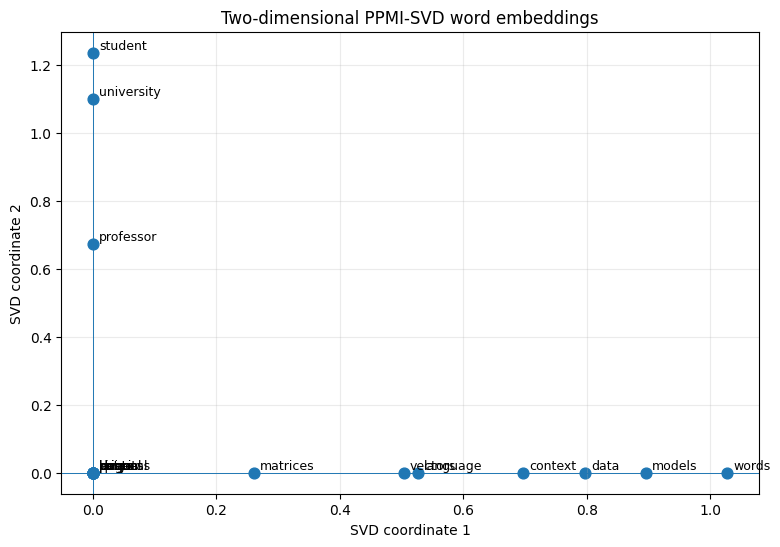

In [17]:
# Choose a readable subset of words to label.
plot_words = [
    "language", "models", "words", "context", "vectors", "matrices", "data",
    "student", "professor", "university", "doctor", "nurse", "hospital",
    "king", "queen", "prince", "princess", "cat", "dog", "animal"
]
plot_words = [w for w in plot_words if w in word_to_id]
plot_ids = [word_to_id[w] for w in plot_words]

plt.figure(figsize=(9, 6))
plt.scatter(E2[plot_ids, 0], E2[plot_ids, 1], s=60)
for w, idx in zip(plot_words, plot_ids):
    plt.text(E2[idx, 0] + 0.01, E2[idx, 1] + 0.01, w, fontsize=9)
plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)
plt.xlabel("SVD coordinate 1")
plt.ylabel("SVD coordinate 2")
plt.title("Two-dimensional PPMI-SVD word embeddings")
plt.grid(True, alpha=0.25)
plt.show()


## Optional interactive Plotly visualization

The following cell creates a hoverable scatter plot in Colab.


In [18]:
try:
    import plotly.express as px
    plot_df = emb2_df.loc[plot_words].reset_index().rename(columns={"index": "word"})
    fig = px.scatter(
        plot_df,
        x="z1",
        y="z2",
        text="word",
        hover_name="word",
        title="Interactive PPMI-SVD word embedding map"
    )
    fig.update_traces(textposition="top center")
    fig.update_layout(xaxis_title="SVD coordinate 1", yaxis_title="SVD coordinate 2")
    fig.show()
except Exception as e:
    print("Plotly visualization skipped:", e)


# Part 10. Analogy arithmetic

Analogy questions use vector arithmetic. The classic form is

$$
a:b \approx c:?
$$

and the query vector is

$$
e(b)-e(a)+e(c).
$$

Then we search for the word vector with largest cosine similarity to the query vector.

In tiny corpora, analogy arithmetic is usually unstable. To understand the geometry clearly, we first use hand-designed vectors.


In [19]:
toy_words = ["man", "woman", "king", "queen", "prince", "princess", "doctor", "nurse"]

toy_E = np.array([
    [0.0, 0.0],   # man
    [1.0, 0.0],   # woman
    [0.2, 1.0],   # king
    [1.2, 1.0],   # queen
    [0.2, 0.6],   # prince
    [1.2, 0.6],   # princess
    [0.0, -0.7],  # doctor
    [0.9, -0.7],  # nurse
])

toy_id = {w: i for i, w in enumerate(toy_words)}

def analogy(a, b, c, words, E, word_to_id_local, k=5):
    En = row_normalize(E)
    query = E[word_to_id_local[b]] - E[word_to_id_local[a]] + E[word_to_id_local[c]]
    query_n = query / max(np.linalg.norm(query), 1e-12)
    scores = En @ query_n
    excluded = {a, b, c}
    rows = []
    for j in np.argsort(-scores):
        if words[j] not in excluded:
            rows.append((words[j], float(scores[j])))
        if len(rows) == k:
            break
    return pd.DataFrame(rows, columns=["candidate", "cosine"])

analogy("man", "woman", "king", toy_words, toy_E, toy_id, k=5)


,candidate,cosine
0,queen,1.000000
1,princess,0.973417
2,prince,0.850265
3,nurse,0.213362
4,doctor,-0.640184


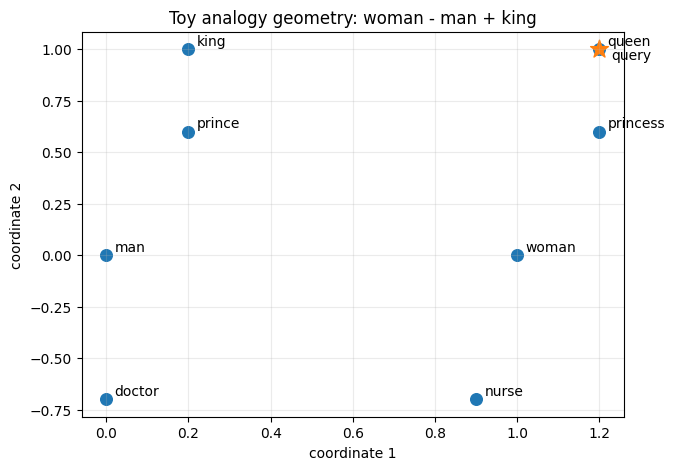

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(toy_E[:, 0], toy_E[:, 1], s=70)
for w, (x, y) in zip(toy_words, toy_E):
    plt.text(x + 0.02, y + 0.02, w, fontsize=10)

query = toy_E[toy_id["woman"]] - toy_E[toy_id["man"]] + toy_E[toy_id["king"]]
plt.scatter([query[0]], [query[1]], marker="*", s=180)
plt.text(query[0] + 0.03, query[1] - 0.05, "query", fontsize=10)
plt.title("Toy analogy geometry: woman - man + king")
plt.xlabel("coordinate 1")
plt.ylabel("coordinate 2")
plt.grid(True, alpha=0.25)
plt.show()


**Interpretation.** Analogy arithmetic works when relationships are encoded as approximately parallel displacement vectors. It is not guaranteed by the definition of an embedding.


# Part 11. Prediction-based embeddings: negative sampling

The count-based method started from a co-occurrence matrix. Prediction-based embeddings instead learn vectors that help distinguish observed word-context pairs from random noise pairs.

For a positive pair $(w,c)$ and negative samples $n_1,\dots,n_K$, the negative-sampling loss is

$$
\ell(w,c)=-\log\sigma(u_c^Tv_w)-\sum_{r=1}^K\log\sigma(-u_{n_r}^Tv_w),
$$

where

$$
\sigma(x)=\frac{1}{1+e^{-x}}.
$$

The positive pair is pushed toward a larger inner product. Negative pairs are pushed toward smaller inner products.


In [21]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def ns_loss_for_pair(V_in, U_out, center_id, context_id, negative_ids):
    v = V_in[center_id]
    loss = np.logaddexp(0.0, -(U_out[context_id] @ v))
    for n in negative_ids:
        loss += np.logaddexp(0.0, U_out[n] @ v)
    return float(loss)

def negative_sampling_step(V_in, U_out, center_id, context_id, negative_ids, lr=0.025):
    v = V_in[center_id].copy()

    # Positive term: -log sigmoid(u_c^T v)
    score_pos = U_out[context_id] @ v
    grad_v = (sigmoid(score_pos) - 1.0) * U_out[context_id]
    grad_u_pos = (sigmoid(score_pos) - 1.0) * v

    # Negative terms: -log sigmoid(-u_n^T v)
    grad_u_negs = []
    for n in negative_ids:
        score_neg = U_out[n] @ v
        g = sigmoid(score_neg)
        grad_v += g * U_out[n]
        grad_u_negs.append((n, g * v))

    V_in[center_id] -= lr * grad_v
    U_out[context_id] -= lr * grad_u_pos
    for n, grad_u in grad_u_negs:
        U_out[n] -= lr * grad_u

    return V_in, U_out

print("Negative-sampling functions are ready.")


Negative-sampling functions are ready.


## Train a tiny model

This is not optimized code. It is written for mathematical transparency.


In [22]:
# Noise distribution often uses unigram counts raised to the 3/4 power.
unigram = np.array([counts[id_to_word[i]] for i in range(d)], dtype=float)
noise_prob = unigram**0.75
noise_prob = noise_prob / noise_prob.sum()

embedding_dim = 2
V_in = rng.normal(0, 0.1, size=(d, embedding_dim))
U_out = rng.normal(0, 0.1, size=(d, embedding_dim))

num_epochs = 80
K = 5
lr = 0.04
loss_history = []

pairs_array = np.array(pairs, dtype=int)

for epoch in range(num_epochs):
    rng.shuffle(pairs_array)
    total_loss = 0.0
    for center_id, context_id in pairs_array:
        neg_ids = rng.choice(d, size=K, replace=True, p=noise_prob)
        total_loss += ns_loss_for_pair(V_in, U_out, center_id, context_id, neg_ids)
        V_in, U_out = negative_sampling_step(V_in, U_out, center_id, context_id, neg_ids, lr=lr)
    loss_history.append(total_loss / len(pairs_array))

print("Initial average loss:", round(loss_history[0], 4))
print("Final average loss:", round(loss_history[-1], 4))


Initial average loss: 4.1584
Final average loss: 2.1458


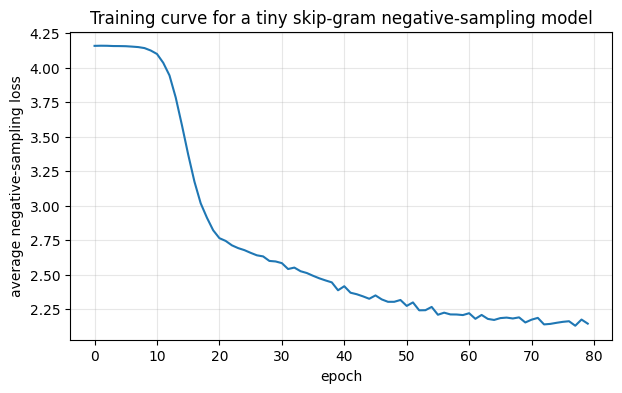

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("average negative-sampling loss")
plt.title("Training curve for a tiny skip-gram negative-sampling model")
plt.grid(True, alpha=0.3)
plt.show()


## Inspect learned neighbors

The input embedding matrix $V_{in}$ now contains learned center-word embeddings.


In [24]:
for word in ["language", "student", "king", "doctor", "vectors"]:
    print(f"Nearest neighbors of {word!r} using trained negative-sampling vectors")
    display(nearest_neighbors(word, V_in, k=6))


Nearest neighbors of 'language' using trained negative-sampling vectors


,neighbor,cosine
0,central,0.999993
1,trains,0.999938
2,by,0.999906
3,relations,0.999744
4,optimization,0.999525
5,processing,0.998873


Nearest neighbors of 'student' using trained negative-sampling vectors


,neighbor,cosine
0,lecture,0.999998
1,animal,0.999969
2,woman,0.999911
3,girl,0.999905
4,theorem,0.999893
5,university,0.999837


Nearest neighbors of 'king' using trained negative-sampling vectors


,neighbor,cosine
0,loss,0.999878
1,space,0.999523
2,in,0.997499
3,queen,0.996962
4,functions,0.996719
5,semantic,0.992649


Nearest neighbors of 'doctor' using trained negative-sampling vectors


,neighbor,cosine
0,eigenvectors,1.000000
1,nurse,0.999977
2,matrices,0.999724
3,values,0.999558
4,reveal,0.999414
5,linear,0.999285


Nearest neighbors of 'vectors' using trained negative-sampling vectors


,neighbor,cosine
0,throne,0.999940
1,royal,0.999597
2,embeddings,0.998813
3,networks,0.998321
4,document,0.998300
5,studies,0.997608


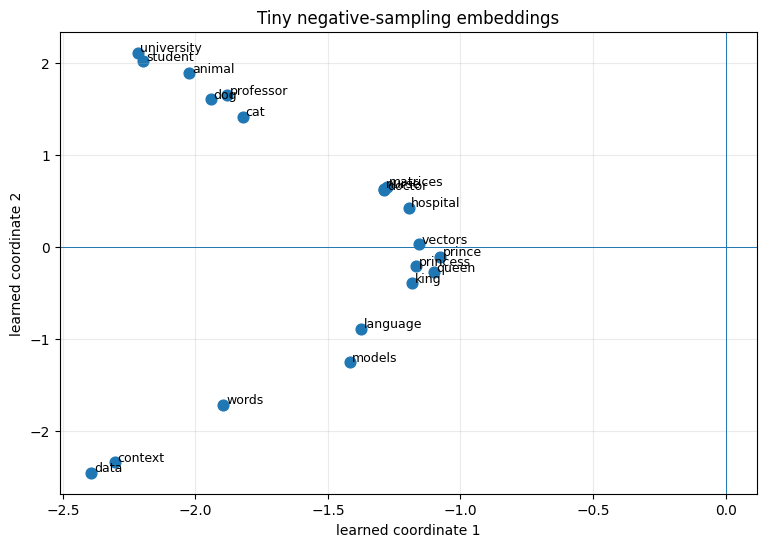

In [25]:
plt.figure(figsize=(9, 6))
plt.scatter(V_in[plot_ids, 0], V_in[plot_ids, 1], s=60)
for w, idx in zip(plot_words, plot_ids):
    plt.text(V_in[idx, 0] + 0.01, V_in[idx, 1] + 0.01, w, fontsize=9)
plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)
plt.xlabel("learned coordinate 1")
plt.ylabel("learned coordinate 2")
plt.title("Tiny negative-sampling embeddings")
plt.grid(True, alpha=0.25)
plt.show()


## Important limitation

This tiny model is useful for understanding the mechanism, but the corpus is too small for reliable semantic embeddings. Real word embeddings require much larger corpora, careful preprocessing, and systematic evaluation.


# Part 12. Bias, polysemy, and model auditing

Static word embeddings have one vector per word type. This creates several limitations:

1. **Polysemy:** the word "bank" may refer to a river bank or a financial bank.
2. **Corpus bias:** embeddings reflect patterns in the data, including social and historical biases.
3. **Frequency effects:** common words can dominate neighborhoods.
4. **No word order:** static word embeddings do not represent full sentence syntax.
5. **Anisotropy and hubness:** some vectors may become nearest neighbors of many unrelated words.

A good mathematical audit asks not only whether neighbors look plausible, but why they appeared.


In [26]:
def embedding_audit_table(words, E):
    rows = []
    En = row_normalize(E)
    norms = np.linalg.norm(E, axis=1)
    for w in words:
        idx = word_to_id[w]
        nn = nearest_neighbors(w, E, k=3)
        rows.append({
            "word": w,
            "frequency": counts[w],
            "embedding_norm": norms[idx],
            "top_neighbors": ", ".join(nn["neighbor"].tolist())
        })
    return pd.DataFrame(rows)

embedding_audit_table(["language", "models", "student", "king", "doctor", "vectors"], E5)


,word,frequency,embedding_norm,top_neighbors
0,language,2,6.397135e-01,"to, distributions, models"
1,models,4,1.094375e+00,"language, to, distributions"
2,student,2,1.236200e+00,"classroom, course, exam"
3,king,1,8.476360e-01,"crown, palace, throne"
4,doctor,1,4.882696e-16,"palace, king, princess"
5,vectors,4,1.182489e+00,"document, with, query"


# Guided exercises

## Exercise 1. Window size

Change `window=2` to `window=1` and `window=3`. Recompute the co-occurrence matrix, PPMI matrix, SVD embeddings, and nearest neighbors.

Questions:

1. Which words become closer when the window is smaller?
2. Which words become closer when the window is larger?
3. Does a larger window emphasize topic more than local syntax?


## Exercise 2. Top PMI pairs

Modify `top_pmi_pairs` to return only pairs with count at least 2.

Question: Why can high-PMI pairs with count 1 be misleading?


## Exercise 3. Embedding dimension

Compare rank-2, rank-5, and rank-10 PPMI-SVD embeddings.

Questions:

1. How much SVD energy is captured by each dimension?
2. Which nearest neighbors are stable?
3. Which nearest neighbors change substantially?


## Exercise 4. Negative sampling

Change the number of negative samples `K` from 5 to 2 and 10.

Questions:

1. How does the training curve change?
2. Do nearest neighbors become more or less stable?
3. Why does negative sampling depend on the noise distribution?


## Exercise 5. Corpus design

Add 10 new sentences about one domain, such as medicine, finance, mathematics, or university advising. Re-run the full pipeline.

Questions:

1. Which new word clusters appear?
2. Which old neighborhoods change?
3. What does this show about corpus dependence?


# Mini-project. Build and audit word embeddings for a domain corpus

Choose a small domain corpus. Possible choices:

- course catalog descriptions;
- abstracts from a research area;
- advising pages;
- textbook chapter summaries;
- a set of short news paragraphs;
- documentation pages for a software library.

Build word embeddings using this pipeline:

1. tokenize the corpus;
2. build a vocabulary;
3. construct word-context pairs;
4. build the co-occurrence matrix;
5. compute PMI and PPMI;
6. compute SVD embeddings;
7. find nearest neighbors of at least 10 important words;
8. visualize a two-dimensional map;
9. write a mathematical audit.

Your audit should answer:

- What does a co-occurrence row mean?
- What does PMI emphasize?
- How much SVD energy is captured by your chosen dimension?
- Which neighborhoods are meaningful?
- Which neighborhoods are artifacts of the small corpus?
- What biases or missing contexts might the corpus contain?


# AI-assisted reflection prompts

Use an AI assistant as a mathematical reviewer, not as an authority.

## Prompt 1

> Explain word embeddings as low-dimensional summaries of empirical context distributions. Include co-occurrence matrices, PMI, PPMI, and SVD.

Check whether the answer clearly connects rows of the co-occurrence matrix to context distributions.

## Prompt 2

> I found the nearest neighbors of a word using cosine similarity. Give a checklist for deciding whether the neighbors reflect semantics, syntax, frequency effects, or corpus bias.

Check whether the answer mentions corpus size, preprocessing, word frequency, vector norms, and the difference between association and truth.

## Prompt 3

> Derive the negative-sampling loss for skip-gram embeddings and explain why positive pairs are pulled together while negative pairs are pushed apart.

Compare the answer with the update formulas in this lab.


# Summary

In this lab you built two routes to word embeddings.

The count-based route was:

$$
\text{tokens} \to C \to \operatorname{PPMI}(C) \to \text{SVD} \to E.
$$

The prediction-based route was:

$$
\text{observed pairs vs. noise pairs} \to \text{negative-sampling loss} \to \text{learned embedding matrix}.
$$

Both approaches turn discrete words into vectors. The resulting geometry is useful, but it is not magic: it reflects corpus statistics, modeling choices, optimization objectives, and limitations of the data.
